# Thermodynamic states
For higher $\gamma$, the thermalisation efficiency is lower, but most of the
dissipation still happens at high $\gamma$, because the kinetic energy is very
high for those gas, that a slightly lower thermalization efficiency (goes from 1
to 0.56 so never too low) doesn't prohibit their dissipation from dominating.

In [1]:
# Shared setup: run this cell, then either analysis section.
%load_ext autoreload
%autoreload 2
import importlib
import sys

# Import the actual package, not the outer dev/ source directory.
sys.path.insert(0, "/zfsstore/user/hey4/rich_tde/dev")

# isort: split
import dev

# isort: split
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import unyt as u

import richio

# Reapply the style on reruns, including kernels that cached the outer namespace.
importlib.reload(dev)

ADIABAT_LEVELS = u.unyt_array(np.linspace(1, 9, 50) * 1e9, "erg/(g*K)")
ADIABAT_GRID_SIZE = 300
# Isotropic blackbody radiation at the gas temperature (LTE): P_rad = a T^4 / 3.
A_RAD = (4 * u.stefan_boltzmann_constant / u.clight).to("erg/(cm**3*K**4)")

### Single-snapshot phase diagrams

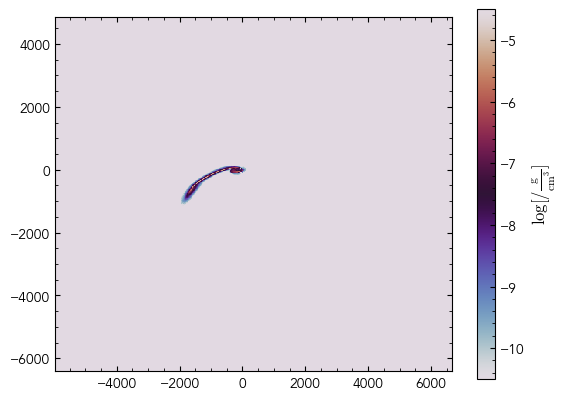

In [2]:
path = "/data1/projects/pi-rossiem/TDE_data/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes/snap_full_100.h5"
snap = richio.load(path)
snap.plots.peek()
plt.show()

In [3]:
gamma = 1 + snap.P / snap.sie / snap.rho

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: invalid value encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


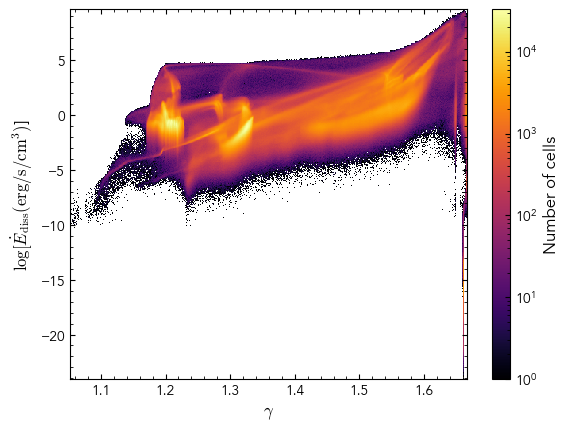

In [5]:
x = gamma
y = np.log10(snap.dissipation.in_cgs())
y_isnan = np.isnan(y)  # there are negative dissipation
x = x[~y_isnan]
y = y[~y_isnan]

plt.hist2d(x, y, bins=500, norm=colors.LogNorm(), cmap="inferno")
plt.colorbar(label="Number of cells")
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$\log[\dot E_\mathrm{diss} \mathrm{(erg/s/cm^3)}$]")
plt.show()

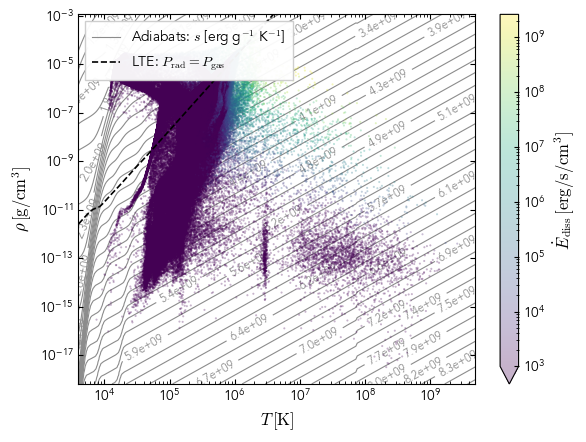

In [ ]:
# Select positive dissipation
diss = snap.dissipation.in_cgs()
positive = diss > 0
diss = diss[positive]
temperature = snap.T[positive]
density = snap.rho[positive].to("g/cm**3")

star_mask = snap.mask_star_ratio()[positive]
diss = diss[star_mask][::100]
temperature = temperature[star_mask][::100]
density = density[star_mask][::100]

fig, ax = plt.subplots()
points = ax.scatter(
    temperature,
    density,
    c=diss,
    norm=colors.LogNorm(vmin=1e3),
    marker=".",
    s=1,
    zorder=2,
    alpha=0.3,
)
fig.colorbar(
    points, ax=ax, label=r"$\dot{E}_\mathrm{diss}\,\mathrm{[erg/s/cm^3]}$", extend="min"
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"$T\,\mathrm{[K]}$",
    ylabel=r"$\rho\,\mathrm{[g/cm^3]}$",
)
# ax.set(xlim=(1e3, 1e11), ylim=(1e-14, 1e0))
temperature_limits, density_limits = ax.get_xlim(), ax.get_ylim()

# RICH specific entropy on the plotted (density, temperature) grid.
T_grid = u.unyt_array(np.geomspace(*temperature_limits, ADIABAT_GRID_SIZE), "K")
rho_grid = u.unyt_array(np.geomspace(*density_limits, ADIABAT_GRID_SIZE), "g/cm**3")
P_grid = richio.eos.dT2p(rho_grid[:, None], T_grid[None, :])
s_grid = richio.eos.dp2s(rho_grid[:, None], P_grid)
adiabats = ax.contour(
    T_grid,
    rho_grid,
    s_grid.value,  # contourpy requires plain Z values; entropy is already in CGS.
    levels=ADIABAT_LEVELS,
    colors="0.55",
    linewidths=0.8,
    zorder=1,
)
labels = ax.clabel(adiabats, inline=True, fmt="%.1e", fontsize="x-small", zorder=1.5)
# for label in labels:
#     label.set_bbox(
#         {"facecolor": "none", "edgecolor": "none", "alpha": 0.8, "pad": 0.5}
#     )
ax.plot([], [], color="0.55", lw=0.8, label=r"Adiabats: $s$ [erg g$^{-1}$ K$^{-1}$]")
# EOS pressure is gas pressure; radiation is evaluated at the same T (LTE).
P_rad_grid = A_RAD * T_grid**4 / 3
pressure_ratio = np.log10((P_grid / P_rad_grid[None, :]).to_value("dimensionless"))
pressure_equality = ax.contour(
    T_grid,
    rho_grid,
    pressure_ratio,
    levels=[0],
    colors="k",
    linestyles="--",
    linewidths=1.2,
    zorder=2,
)
ax.plot([], [], "k--", lw=1.2, label=r"LTE: $P_\mathrm{rad}=P_\mathrm{gas}$")
ax.legend(
    loc="upper left", fontsize="small", facecolor="white", framealpha=0.95
)
ax.set(xlim=temperature_limits, ylim=density_limits)
plt.show()

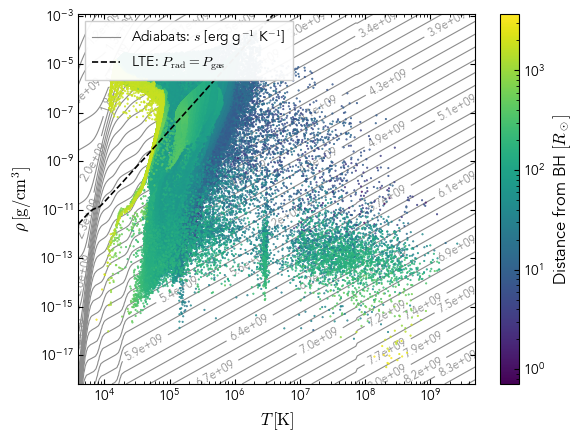

In [8]:
# Same cells as above, colored by distance from the BH.
diss = snap.dissipation.in_cgs()
positive = diss > 0
diss = diss[positive]
temperature = snap.T[positive]
density = snap.rho[positive].to("g/cm**3")

star_mask = snap.mask_star_ratio()[positive]
diss = diss[star_mask][::100]
temperature = temperature[star_mask][::100]
density = density[star_mask][::100]

# This snapshot is already in the BH frame.
distance = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2).to("Rsun")
distance = distance[positive][star_mask][::100]

fig, ax = plt.subplots()
points = ax.scatter(
    temperature,
    density,
    c=distance,
    norm=colors.LogNorm(),
    marker=".",
    s=1,
    zorder=2,
    # alpha=0.3,
)
fig.colorbar(points, ax=ax, label=r"Distance from BH $[R_\odot]$")
ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"$T\,\mathrm{[K]}$",
    ylabel=r"$\rho\,\mathrm{[g/cm^3]}$",
)
# ax.set(xlim=(1e3, 1e7), ylim=(1e-14, 1e0))
temperature_limits, density_limits = ax.get_xlim(), ax.get_ylim()

# RICH specific entropy on the plotted (density, temperature) grid.
T_grid = u.unyt_array(np.geomspace(*temperature_limits, ADIABAT_GRID_SIZE), "K")
rho_grid = u.unyt_array(np.geomspace(*density_limits, ADIABAT_GRID_SIZE), "g/cm**3")
P_grid = richio.eos.dT2p(rho_grid[:, None], T_grid[None, :])
s_grid = richio.eos.dp2s(rho_grid[:, None], P_grid)
adiabats = ax.contour(
    T_grid,
    rho_grid,
    s_grid.value,  # contourpy requires plain Z values; entropy is already in CGS.
    levels=ADIABAT_LEVELS,
    colors="0.55",
    linewidths=0.8,
    zorder=1,
)
labels = ax.clabel(adiabats, inline=True, fmt="%.1e", fontsize="x-small", zorder=1.5)
# for label in labels:
#     label.set_bbox(
#         {"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 0.5}
#     )
ax.plot([], [], color="0.55", lw=0.8, label=r"Adiabats: $s$ [erg g$^{-1}$ K$^{-1}$]")
# EOS pressure is gas pressure; radiation is evaluated at the same T (LTE).
P_rad_grid = A_RAD * T_grid**4 / 3
pressure_ratio = np.log10((P_grid / P_rad_grid[None, :]).to_value("dimensionless"))
pressure_equality = ax.contour(
    T_grid,
    rho_grid,
    pressure_ratio,
    levels=[0],
    colors="k",
    linestyles="--",
    linewidths=1.2,
    zorder=2,
)
ax.plot([], [], "k--", lw=1.2, label=r"LTE: $P_\mathrm{rad}=P_\mathrm{gas}$")
ax.legend(
    loc="upper left", fontsize="small", frameon=True, facecolor="white", framealpha=0.95
)
ax.set(xlim=temperature_limits, ylim=density_limits)
plt.show()

### Cell histories
Run the shared setup, then this section directly. We plot ten of the 2,712 full-run survivors (`full_run_ids[::270][:10]`) and ten of the 205 nozzle candidates (`nozzle_ids[::20][:10]`). Full histories are retained; no additional selection cuts are applied.

Filled circles mark full-run endpoints and filled squares mark nozzle endpoints. A track has the same endpoint colour and shape in both plots; open circles mark starts. The $\rho$–$T$ lines remain coloured by BH distance. The dashed equality curve uses EOS gas pressure and $P_\mathrm{rad}=4\sigma_\mathrm{SB}T^4/(3c)$.

The next three cells define the paths, units and `read_track(ID)`, which returns a dictionary of arrays with units:

```python
track = read_track(791839)
track["time"].to("day")
track["density"].to("g/cm**3")
track["temperature"]
track["x"].to("AU")  # BH-centred; likewise y, z, radius
```

Nozzle candidates have at least two samples with $t>0.5t_\mathrm{fb}$, three-dimensional $r<2r_\mathrm{p}$ and BH-frame $x>0$, within a continuous history lasting at least $1.5t_\mathrm{fb}$. Most of their history precedes the nozzle samples; post-nozzle coverage is short. Persistent mesh IDs exchange mass and are not exact fluid parcels.


In [2]:
# Setup used only by the trajectory section.
import os
from bisect import bisect_left

import h5py
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, ScalarFormatter

REPO_DIR = os.path.abspath(os.path.join(os.path.dirname(dev.__file__), "..", ".."))
sys.path.insert(0, os.path.join(REPO_DIR, "works", "movies"))

TRACK_RUN = "1e4"
TRACK_DATA_DIR = os.path.join(
    REPO_DIR, "data", "processed", "ThermodynamicTracks", TRACK_RUN
)
NOZZLE_ID_FILE = os.path.join(TRACK_DATA_DIR, "nozzle", "ids.txt")
TRACK_ENSEMBLE_FILE = os.path.join(TRACK_DATA_DIR, "one-tfb", "histories.h5")
TRACK_CMAP = "viridis"
TRACK_FRAME_SWITCH = 21
TRACK_BETA = 1

In [3]:
# Convert the stored columns to familiar physical units.
def history_quantities(snapshots, time_code, values):
    return {
        "snapshot": snapshots,
        "time": u.unyt_array(time_code, richio.units.get_unit("Time")).to("day"),
        "density": u.unyt_array(values[:, 0], richio.units.get_unit("Density")).to(
            "g/cm**3"
        ),
        "temperature": u.unyt_array(values[:, 1], "K"),
        "dissipation": u.unyt_array(
            values[:, 2], richio.units.get_unit("Dissipation")
        ).to("erg/(s*cm**3)"),
        "star_fraction": values[:, 3],
        "was_removed": values[:, 4],
        "position_stored": u.unyt_array(values[:, 5:8], richio.units.lscale).to("Rsun"),
        "pressure": u.unyt_array(values[:, 8], richio.units.get_unit("Pressure")).to(
            "dyn/cm**2"
        ),
        "internal_energy": u.unyt_array(
            values[:, 9], richio.units.get_unit("InternalEnergy")
        ).to("erg/g"),
    }


with h5py.File(TRACK_ENSEMBLE_FILE, "r") as archive:
    assert tuple(archive["fields"].asstr()[:]) == (
        "Density",
        "Temperature",
        "Dissipation",
        "tracers/Star",
        "tracers/WasRemoved",
        "X",
        "Y",
        "Z",
        "Pressure",
        "InternalEnergy",
    )
    n_ids = len(archive["ids"])
    catalogue_snapshots = archive["snapshots"][:]
    catalogue_time_code = archive["time_code"][:]
    fallback_time = u.unyt_quantity(
        archive.attrs["fallback_time_code"], richio.units.tscale
    ).to("day")
print(f"{n_ids:,} available IDs; minimum duration = {fallback_time:.6f}.")

15,077,536 available IDs; minimum duration = 2.656021 day.


In [4]:
from dev.datapaths import TDE_PARAMETERS
from tde_frame import star_orbit_x0

mbh, mstar, rstar = TDE_PARAMETERS[TRACK_RUN]
r_p = u.unyt_quantity(
    rstar * (mbh / mstar) ** (1 / 3) / TRACK_BETA, richio.units.lscale
).to("Rsun")
# One offset per catalogue snapshot, indexed separately for every track.
frame_offset = u.unyt_array(np.zeros((len(catalogue_snapshots), 3)), "Rsun")
for row in np.flatnonzero(catalogue_snapshots < TRACK_FRAME_SWITCH):
    state = star_orbit_x0(
        catalogue_time_code[row], m_bh=mbh, m_star=mstar, r_star=rstar, beta=TRACK_BETA
    )
    frame_offset[row, :2] = u.unyt_array(state[:2], richio.units.lscale)


def read_track(particle_id):
    """Read one ID's history as unitful arrays, with BH-centred x/y/z and radius.

    Keys: snapshot, time, density, temperature, dissipation, star_fraction,
    was_removed, pressure, internal_energy, position_stored, position, x, y, z,
    radius. All arrays follow saved-snapshot order. This census has one interval
    per ID; lookup reads only a few ID entries and the selected history rows.
    """
    particle_id = np.uint64(particle_id)
    with h5py.File(TRACK_ENSEMBLE_FILE, "r") as archive:
        ids = archive["ids"]  # HDF5 dataset; do not load the whole ID list.
        row = bisect_left(ids, particle_id)
        if row == len(ids) or ids[row] != particle_id:
            raise KeyError(f"ID {particle_id} is not in this census.")
        start, stop = archive["offsets"][row : row + 2]
        indices = archive["snapshot_index"][start:stop]
        values = archive["values"][start:stop]
    track = history_quantities(
        catalogue_snapshots[indices], catalogue_time_code[indices], values
    )
    track["position"] = track["position_stored"] + frame_offset[indices]
    track["x"], track["y"], track["z"] = track["position"].T
    track["radius"] = np.sqrt(np.sum(track["position"] ** 2, axis=1))
    return track


print(f"BH-centred coordinates; r_p = {r_p:.2f} = {r_p.to('AU'):.4f}")

BH-centred coordinates; r_p = 12.84 Rsun = 0.0597 AU


In [8]:
# Full-run survivors: use only interval metadata to find the 2,712 IDs.
with h5py.File(TRACK_ENSEMBLE_FILE, "r") as archive:
    full_run_rows = np.flatnonzero(
        (archive["start_index"][:] == 0)
        & (archive["end_index"][:] == len(catalogue_snapshots) - 1)
    )
    full_run_ids = archive["ids"][full_run_rows]
nozzle_ids = np.loadtxt(NOZZLE_ID_FILE, dtype=np.uint64, ndmin=1)

# Each uncapped stride gives eleven; retain exactly ten from each catalogue.
full_run_sample = full_run_ids[::270][:10]
nozzle_sample = nozzle_ids[::20][:10]
track_ids = np.concatenate((full_run_sample, nozzle_sample))
tracks = {int(particle_id): read_track(particle_id) for particle_id in track_ids}

for track in tracks.values():
    track["entropy"] = richio.eos.dp2s(track["density"], track["pressure"])
entropy_norm = colors.Normalize(
    vmin=min(track["entropy"].min() for track in tracks.values()),
    vmax=max(track["entropy"].max() for track in tracks.values()),
)
entropy_cmap = plt.get_cmap(TRACK_CMAP)

# The same colour + endpoint shape identifies a track in both plots.
track_palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
track_colors = {}
track_markers = {}
track_linestyles = {}
for sample, marker, linestyle in (
    (full_run_sample, "o", "-"),
    (nozzle_sample, "s", "--"),
):
    for index, particle_id in enumerate(sample):
        track_colors[int(particle_id)] = track_palette[index % len(track_palette)]
        track_markers[int(particle_id)] = marker
        track_linestyles[int(particle_id)] = linestyle

print(f"Full run: {len(full_run_sample)} / {len(full_run_ids):,}; filled circles.")
print(f"Nozzle: {len(nozzle_sample)} / {len(nozzle_ids):,}; filled squares.")
print("Endpoint colours match across plots; open circles mark starts.")

Full run: 10 / 2,712; filled circles.
Nozzle: 10 / 205; filled squares.
Endpoint colours match across plots; open circles mark starts.


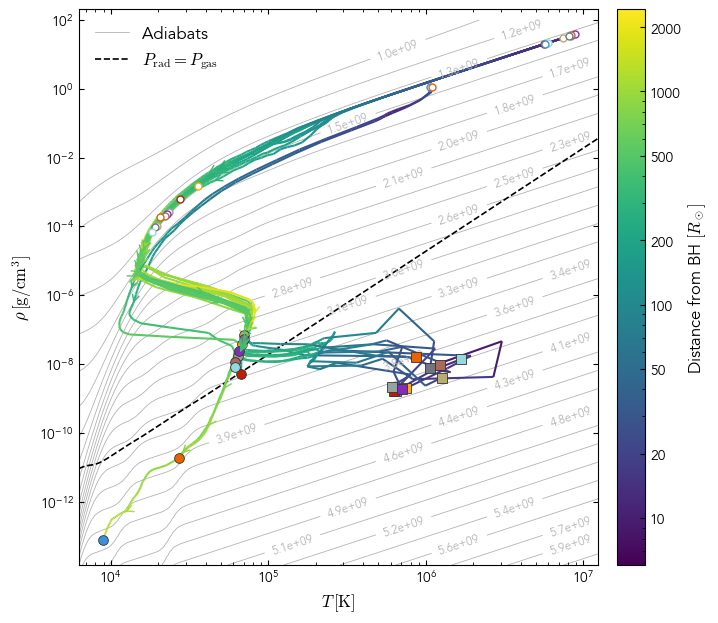

In [14]:
distance_norm = colors.LogNorm(
    vmin=min(track["radius"].min() for track in tracks.values()),
    vmax=max(track["radius"].max() for track in tracks.values()),
)
distance_cmap = plt.get_cmap(TRACK_CMAP)
fig, ax = plt.subplots(figsize=(7.4, 6.4))
for particle_id, track in tracks.items():
    marker = track_markers[particle_id]
    color = track_colors[particle_id]
    temperature, density, radius = (
        track["temperature"],
        track["density"],
        track["radius"],
    )
    # LineCollection needs a plain vertex array with mixed coordinate units.
    vertices = np.column_stack((temperature.to_value("K"), density.to_value("g/cm**3")))
    segments = np.stack((vertices[:-1], vertices[1:]), axis=1)
    trajectory = LineCollection(
        segments, cmap=distance_cmap, norm=distance_norm, linewidths=1.5, zorder=3
    )
    trajectory.set_array((radius[:-1] + radius[1:]) / 2)
    ax.add_collection(trajectory)
    ax.plot(
        temperature[0],
        density[0],
        "o",
        mfc="white",
        mec=color,
        ms=5,
        mew=1,
        zorder=4,
    )
    ax.plot(
        temperature[-1],
        density[-1],
        marker=marker,
        linestyle="none",
        color=color,
        mec="0.2",
        mew=0.6,
        ms=7,
        zorder=4,
    )
    for sample in np.linspace(0, len(temperature) - 2, 5, dtype=int)[1:-1]:
        ax.annotate(
            "",
            xy=(temperature[sample + 1], density[sample + 1]),
            xytext=(temperature[sample], density[sample]),
            arrowprops={
                "arrowstyle": "->",
                "color": distance_cmap(distance_norm(radius[sample])),
                "lw": 1,
            },
            zorder=4,
        )
ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"$T\,\mathrm{[K]}$",
    ylabel=r"$\rho\,\mathrm{[g/cm^3]}$",
)
ax.autoscale_view()
fig.colorbar(
    trajectory,
    ax=ax,
    label=r"Distance from BH $[R_\odot]$",
    pad=0.03,
    ticks=LogLocator(subs=(1, 2, 5)),
    format=ScalarFormatter(),
)
temperature_limits, density_limits = ax.get_xlim(), ax.get_ylim()

# Restrict only the EOS background to the interior of its tabulated domain.
T_grid = u.unyt_array(
    np.geomspace(
        max(temperature_limits[0], 1e3),
        min(temperature_limits[1], 5e7),
        ADIABAT_GRID_SIZE,
    ),
    "K",
)
rho_grid = u.unyt_array(
    np.geomspace(
        max(density_limits[0], 1e-21),
        min(density_limits[1], 1e2),
        ADIABAT_GRID_SIZE,
    ),
    "g/cm**3",
)
P_grid = richio.eos.dT2p(rho_grid[:, None], T_grid[None, :])
s_grid = richio.eos.dp2s(rho_grid[:, None], P_grid)
adiabats = ax.contour(
    T_grid,
    rho_grid,
    s_grid.value,
    levels=ADIABAT_LEVELS,
    colors="0.7",
    linewidths=0.6,
    zorder=1,
)
ax.clabel(adiabats, adiabats.levels, inline=True, fmt="%.1e", fontsize="x-small")
# P_rad = a T^4 / 3, while the EOS supplies P_gas(rho, T).
P_rad_grid = A_RAD * T_grid**4 / 3
pressure_ratio = np.log10((P_grid / P_rad_grid[None, :]).to_value("dimensionless"))
pressure_equality = ax.contour(
    T_grid,
    rho_grid,
    pressure_ratio,
    levels=[0],
    colors="k",
    linestyles="--",
    linewidths=1.2,
    zorder=2,
)
ax.legend(
    handles=[
        Line2D([], [], color="0.7", lw=0.6, label="Adiabats"),
        Line2D(
            [], [], color="k", ls="--", lw=1.2, label=r"$P_\mathrm{rad}=P_\mathrm{gas}$"
        ),
    ],
)
ax.set(xlim=temperature_limits, ylim=density_limits)
fig.tight_layout()
plt.show()

### Volumetric dissipation
The same tracks and endpoint colours, now with line colour showing the mean volumetric dissipation between adjacent samples, in $\mathrm{erg\,s^{-1}\,cm^{-3}}$. Positive rates use a logarithmic scale; non-positive rates are grey.

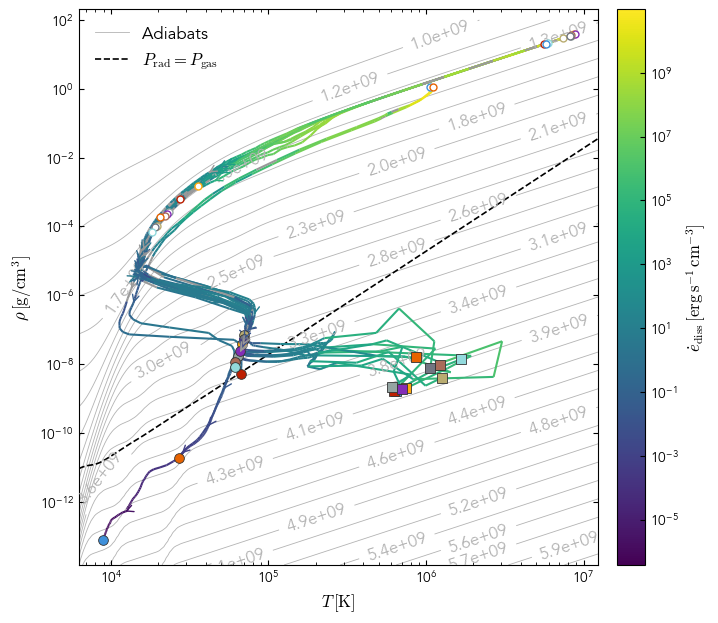

In [7]:
# Colour each segment by its mean volumetric dissipation in erg/(s*cm**3).
segment_dissipation = np.concatenate(
    [
        (track["dissipation"][:-1] + track["dissipation"][1:]) / 2
        for track in tracks.values()
    ]
)
positive_dissipation = segment_dissipation[segment_dissipation > 0]
dissipation_norm = colors.LogNorm(
    vmin=positive_dissipation.min(),
    vmax=positive_dissipation.max(),
)
# LogNorm masks non-positive rates; keep these path segments visible in grey.
dissipation_cmap = plt.get_cmap(TRACK_CMAP).with_extremes(bad="0.6")
fig, ax = plt.subplots(figsize=(7.4, 6.4))
for particle_id, track in tracks.items():
    marker = track_markers[particle_id]
    color = track_colors[particle_id]
    temperature, density, dissipation = (
        track["temperature"],
        track["density"],
        track["dissipation"],
    )
    # LineCollection needs a plain vertex array with mixed coordinate units.
    vertices = np.column_stack((temperature.to_value("K"), density.to_value("g/cm**3")))
    segments = np.stack((vertices[:-1], vertices[1:]), axis=1)
    trajectory = LineCollection(
        segments, cmap=dissipation_cmap, norm=dissipation_norm, linewidths=1.5, zorder=3
    )
    mean_dissipation = (dissipation[:-1] + dissipation[1:]) / 2
    trajectory.set_array(mean_dissipation)
    ax.add_collection(trajectory)
    ax.plot(
        temperature[0],
        density[0],
        "o",
        mfc="white",
        mec=color,
        ms=5,
        mew=1,
        zorder=4,
    )
    ax.plot(
        temperature[-1],
        density[-1],
        marker=marker,
        linestyle="none",
        color=color,
        mec="0.2",
        mew=0.6,
        ms=7,
        zorder=4,
    )
    for sample in np.linspace(0, len(temperature) - 2, 5, dtype=int)[1:-1]:
        ax.annotate(
            "",
            xy=(temperature[sample + 1], density[sample + 1]),
            xytext=(temperature[sample], density[sample]),
            arrowprops={
                "arrowstyle": "->",
                "color": dissipation_cmap(dissipation_norm(mean_dissipation[sample])),
                "lw": 1,
            },
            zorder=4,
        )
ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"$T\,\mathrm{[K]}$",
    ylabel=r"$\rho\,\mathrm{[g/cm^3]}$",
)
ax.autoscale_view()
fig.colorbar(
    trajectory,
    ax=ax,
    label=r"$\dot{e}_\mathrm{diss}\,[\mathrm{erg\,s^{-1}\,cm^{-3}}]$",
    pad=0.03,
)
temperature_limits, density_limits = ax.get_xlim(), ax.get_ylim()

# Restrict only the EOS background to the interior of its tabulated domain.
T_grid = u.unyt_array(
    np.geomspace(
        max(temperature_limits[0], 1e3),
        min(temperature_limits[1], 5e7),
        ADIABAT_GRID_SIZE,
    ),
    "K",
)
rho_grid = u.unyt_array(
    np.geomspace(
        max(density_limits[0], 1e-21),
        min(density_limits[1], 1e2),
        ADIABAT_GRID_SIZE,
    ),
    "g/cm**3",
)
P_grid = richio.eos.dT2p(rho_grid[:, None], T_grid[None, :])
s_grid = richio.eos.dp2s(rho_grid[:, None], P_grid)
adiabats = ax.contour(
    T_grid,
    rho_grid,
    s_grid.value,
    levels=ADIABAT_LEVELS,
    colors="0.7",
    linewidths=0.6,
    zorder=1,
)
ax.clabel(adiabats, adiabats.levels, inline=True, fmt="%.1e")
# P_rad = a T^4 / 3, while the EOS supplies P_gas(rho, T).
P_rad_grid = A_RAD * T_grid**4 / 3
pressure_ratio = np.log10((P_grid / P_rad_grid[None, :]).to_value("dimensionless"))
pressure_equality = ax.contour(
    T_grid,
    rho_grid,
    pressure_ratio,
    levels=[0],
    colors="k",
    linestyles="--",
    linewidths=1.2,
    zorder=2,
)
ax.legend(
    handles=[
        Line2D([], [], color="0.7", lw=0.6, label="Adiabats"),
        Line2D(
            [], [], color="k", ls="--", lw=1.2, label=r"$P_\mathrm{rad}=P_\mathrm{gas}$"
        ),
    ],
)
ax.set(xlim=temperature_limits, ylim=density_limits)
fig.tight_layout()
plt.show()

### Spatial trajectories
Twenty tracks, each drawn in its identifying colour. Open circles mark starts; filled endpoints retain the cell colours used in the other plots. Solid paths with circular endpoints are full-run survivors; dashed paths with square endpoints are nozzle candidates. Both views keep equal spatial scaling; the full-view limits expand to a 2:1 span while enclosing all tracks. In the nozzle view, the dashed circle marks $r_\mathrm{p}$. Lines connect saved samples.


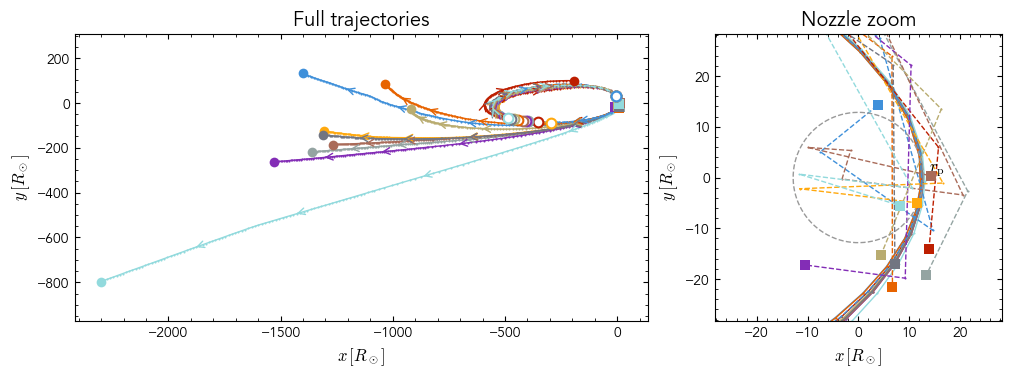

In [6]:
# Zoom limits in units of the pericentre radius; adjust these by hand.
NOZZLE_XLIM_RP = (-2.2, 2.2)
NOZZLE_YLIM_RP = (-2.2, 2.2)

angle = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(
    1, 2, figsize=(10, 3.6), width_ratios=(2, 1), layout="constrained"
)
for ax in axes:
    for particle_id, track in tracks.items():
        x, y, color = track["x"], track["y"], track_colors[particle_id]
        ax.plot(
            x, y, color=color, linestyle=track_linestyles[particle_id], marker=".", ms=3
        )
        for row in np.linspace(0, len(x) - 2, 6, dtype=int)[1:-1]:
            ax.annotate(
                "",
                xy=(x[row + 1], y[row + 1]),
                xytext=(x[row], y[row]),
                arrowprops={
                    "arrowstyle": "->",
                    "color": color,
                },
            )

    # Draw endpoints above the paths, and open starts last so they remain visible.
    for particle_id, track in tracks.items():
        x, y, color = track["x"], track["y"], track_colors[particle_id]
        ax.plot(x[-1], y[-1], track_markers[particle_id], color=color, ms=7, zorder=4)
        ax.plot(x[0], y[0], "o", mfc="white", mec=color, ms=7, mew=1.5, zorder=5)
    ax.plot(0, 0, "k+")
    ax.set(xlabel=r"$x\,[R_\odot]$", ylabel=r"$y\,[R_\odot]$")
    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")

# Expand the limits to a 2:1 span without cropping data or stretching distances.
xlim, ylim = axes[0].get_xlim(), axes[0].get_ylim()
height = max((xlim[1] - xlim[0]) / 2, ylim[1] - ylim[0])
axes[0].set(
    xlim=np.mean(xlim) + height * np.array([-1, 1]),
    ylim=np.mean(ylim) + height * np.array([-0.5, 0.5]),
)
axes[0].set_title("Full trajectories")
axes[1].plot(r_p * np.cos(angle), r_p * np.sin(angle), "--", color="0.6")
axes[1].annotate(
    r"$r_\mathrm{p}$", xy=(r_p, 0), xytext=(4, 4), textcoords="offset points"
)
axes[1].set_title("Nozzle zoom")
axes[1].set(
    xlim=np.asarray(NOZZLE_XLIM_RP) * r_p,
    ylim=np.asarray(NOZZLE_YLIM_RP) * r_p,
)
plt.show()

### Energy and entropy histories
Four of the tracks above, with matching colours and endpoint symbols. Both energies are **specific energies** (erg/g); radiation energy is read from `Erad`, without assuming LTE. Entropy comes from the same EOS as the phase-diagram adiabats. Run the radiation-reading cell once, then rerun the plotting cell freely.


In [9]:
TIME_SERIES_IDS = track_ids[[0, 5, 12, 17]]  # Two full-run and two nozzle tracks.
series_tracks = {
    int(particle_id): tracks[int(particle_id)] for particle_id in TIME_SERIES_IDS
}

# C0, C1, C2, C3 from the default palette loaded by dev.
series_colors = {
    int(particle_id): track_palette[index]
    for index, particle_id in enumerate(TIME_SERIES_IDS)
}

print("Time-series IDs:", [int(particle_id) for particle_id in TIME_SERIES_IDS])

Time-series IDs: [18303, 532382, 2333512679, 4540152605]


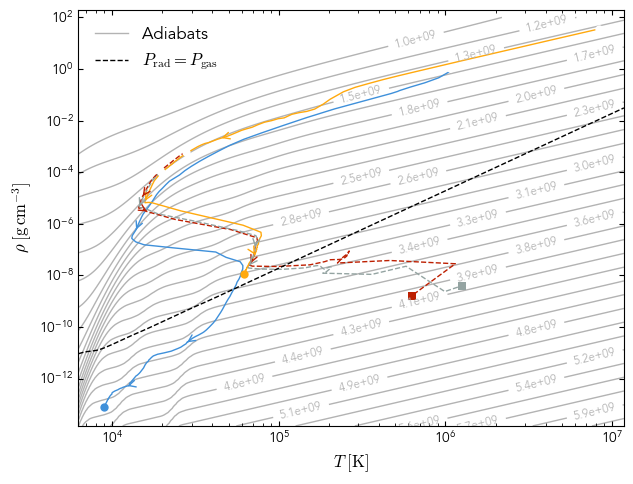

In [15]:
# rho-T histories of the same four examples, in their C0-C3 colours.
fig, ax = plt.subplots(figsize=(6.5, 5))
for particle_id, track in series_tracks.items():
    temperature, density = track["temperature"], track["density"]
    color = series_colors[particle_id]
    ax.plot(
        temperature,
        density,
        color=color,
        linestyle=track_linestyles[particle_id],
    )
    for row in np.linspace(0, len(temperature) - 2, 5, dtype=int)[1:-1]:
        ax.annotate(
            "",
            xy=(temperature[row + 1], density[row + 1]),
            xytext=(temperature[row], density[row]),
            arrowprops={"arrowstyle": "->", "color": color},
        )
    ax.plot(
        temperature[-1],
        density[-1],
        track_markers[particle_id],
        color=color,
    )
    ax.plot(
        temperature[0],
        density[0],
        "o",
        mfc="white",
        mec=color,
    )
ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"$T\;[\mathrm{K}]$",
    ylabel=r"$\rho\;[\mathrm{g\,cm^{-3}}]$",
)
temperature_limits, density_limits = ax.get_xlim(), ax.get_ylim()

# EOS background within the tabulated domain.
T_grid = u.unyt_array(
    np.geomspace(
        max(temperature_limits[0], 1e3),
        min(temperature_limits[1], 5e7),
        ADIABAT_GRID_SIZE,
    ),
    "K",
)
rho_grid = u.unyt_array(
    np.geomspace(
        max(density_limits[0], 1e-21), min(density_limits[1], 1e2), ADIABAT_GRID_SIZE
    ),
    "g/cm**3",
)
P_grid = richio.eos.dT2p(rho_grid[:, None], T_grid[None, :])
s_grid = richio.eos.dp2s(rho_grid[:, None], P_grid)
# Matplotlib contour needs plain Z arrays for its masked-array handling.
adiabats = ax.contour(
    T_grid,
    rho_grid,
    s_grid.to_value("erg/(g*K)"),
    levels=ADIABAT_LEVELS,
    colors="0.7",
    zorder=1,
)
ax.clabel(adiabats, adiabats.levels, inline=True, fmt="%.1e", fontsize="x-small")
pressure_ratio = P_grid / (A_RAD * T_grid[None, :] ** 4 / 3)
ax.contour(
    T_grid,
    rho_grid,
    pressure_ratio.to_value("dimensionless"),
    levels=[1],
    colors="k",
    linestyles="--",
)
ax.legend(
    handles=[
        Line2D([], [], color="0.7", label="Adiabats"),
        Line2D(
            [], [], color="k", linestyle="--", label=r"$P_\mathrm{rad}=P_\mathrm{gas}$"
        ),
    ]
)
ax.set(xlim=temperature_limits, ylim=density_limits)
fig.tight_layout()
plt.show()

### Trajectories of the four history cells
The same `TIME_SERIES_IDS` used below, coloured by EOS specific entropy, with matching start/end markers. Both views keep equal spatial scaling. The full-view limits span 2:1, and both panels have the same height.


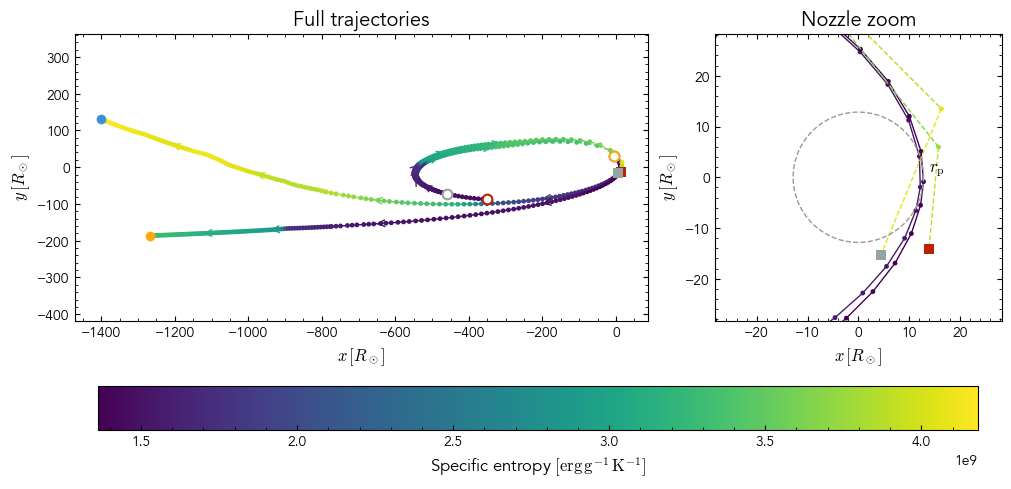

In [11]:
HISTORY_ZOOM_RP = 2.2

angle = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(
    1, 2, figsize=(10, 4.6), width_ratios=(2, 1), layout="constrained"
)
for ax in axes:
    for particle_id, track in series_tracks.items():
        x, y, entropy = track["x"], track["y"], track["entropy"]
        points = np.column_stack((x, y))
        segments = np.stack((points[:-1], points[1:]), axis=1)
        segment_entropy = (entropy[:-1] + entropy[1:]) / 2
        trajectory = LineCollection(
            segments,
            cmap=entropy_cmap,
            norm=entropy_norm,
            linestyles=track_linestyles[particle_id],
        )
        trajectory.set_array(segment_entropy)
        ax.add_collection(trajectory)
        ax.scatter(x, y, c=entropy, cmap=entropy_cmap, norm=entropy_norm, s=6)
        for row in np.linspace(0, len(x) - 2, 6, dtype=int)[1:-1]:
            ax.annotate(
                "",
                xy=(x[row + 1], y[row + 1]),
                xytext=(x[row], y[row]),
                arrowprops={
                    "arrowstyle": "->",
                    "color": entropy_cmap(entropy_norm(segment_entropy[row])),
                },
            )

    # Draw endpoints above the paths, and open starts last so they remain visible.
    for particle_id, track in series_tracks.items():
        x, y, color = track["x"], track["y"], series_colors[particle_id]
        ax.plot(x[-1], y[-1], track_markers[particle_id], color=color, ms=7, zorder=4)
        ax.plot(x[0], y[0], "o", mfc="white", mec=color, ms=7, mew=1.5, zorder=5)
    ax.plot(0, 0, "k+")
    ax.set(xlabel=r"$x\,[R_\odot]$", ylabel=r"$y\,[R_\odot]$")
    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")

# Expand the limits to a 2:1 span without cropping data or stretching distances.
xlim, ylim = axes[0].get_xlim(), axes[0].get_ylim()
height = max((xlim[1] - xlim[0]) / 2, ylim[1] - ylim[0])
axes[0].set(
    xlim=np.mean(xlim) + height * np.array([-1, 1]),
    ylim=np.mean(ylim) + height * np.array([-0.5, 0.5]),
)
axes[0].set_title("Full trajectories")
axes[1].plot(r_p * np.cos(angle), r_p * np.sin(angle), "--", color="0.6")
axes[1].annotate(
    r"$r_\mathrm{p}$", xy=(r_p, 0), xytext=(4, 4), textcoords="offset points"
)
axes[1].set_title("Nozzle zoom")
zoom_limits = np.array([-HISTORY_ZOOM_RP, HISTORY_ZOOM_RP]) * r_p
axes[1].set(xlim=zoom_limits, ylim=zoom_limits)
fig.colorbar(
    trajectory,
    ax=axes,
    orientation="horizontal",
    label=r"Specific entropy $[\mathrm{erg\,g^{-1}\,K^{-1}}]$",
)
plt.show()

### Four-cell trajectories coloured by time
The same four histories, coloured by $t/t_\mathrm{fb}$, with matching start and end markers.


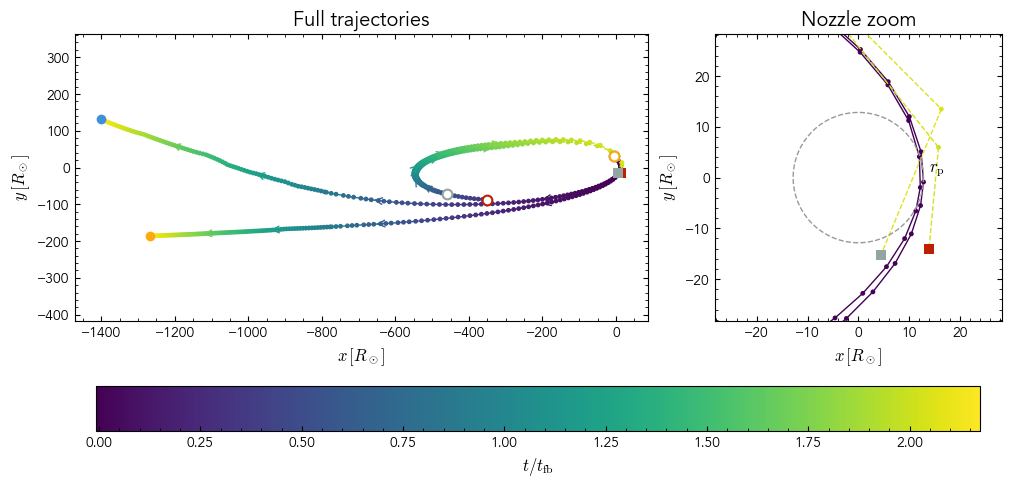

In [8]:
TIME_ZOOM_RP = 2.2
time_norm = colors.Normalize(
    vmin=min((track["time"] / fallback_time).min() for track in series_tracks.values()),
    vmax=max((track["time"] / fallback_time).max() for track in series_tracks.values()),
)
time_cmap = plt.get_cmap(TRACK_CMAP)

angle = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(
    1, 2, figsize=(10, 4.6), width_ratios=(2, 1), layout="constrained"
)
for ax in axes:
    for particle_id, track in series_tracks.items():
        x, y, time = track["x"], track["y"], track["time"] / fallback_time
        points = np.column_stack((x, y))
        segments = np.stack((points[:-1], points[1:]), axis=1)
        segment_time = (time[:-1] + time[1:]) / 2
        trajectory = LineCollection(
            segments,
            cmap=time_cmap,
            norm=time_norm,
            linestyles=track_linestyles[particle_id],
        )
        trajectory.set_array(segment_time)
        ax.add_collection(trajectory)
        ax.scatter(x, y, c=time, cmap=time_cmap, norm=time_norm, s=6)
        for row in np.linspace(0, len(x) - 2, 6, dtype=int)[1:-1]:
            ax.annotate(
                "",
                xy=(x[row + 1], y[row + 1]),
                xytext=(x[row], y[row]),
                arrowprops={
                    "arrowstyle": "->",
                    "color": time_cmap(time_norm(segment_time[row])),
                },
            )

    # Draw endpoints above the paths, and open starts last so they remain visible.
    for particle_id, track in series_tracks.items():
        x, y, color = track["x"], track["y"], series_colors[particle_id]
        ax.plot(x[-1], y[-1], track_markers[particle_id], color=color, ms=7, zorder=4)
        ax.plot(x[0], y[0], "o", mfc="white", mec=color, ms=7, mew=1.5, zorder=5)
    ax.plot(0, 0, "k+")
    ax.set(xlabel=r"$x\,[R_\odot]$", ylabel=r"$y\,[R_\odot]$")
    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")

# Expand the limits to a 2:1 span without cropping data or stretching distances.
xlim, ylim = axes[0].get_xlim(), axes[0].get_ylim()
height = max((xlim[1] - xlim[0]) / 2, ylim[1] - ylim[0])
axes[0].set(
    xlim=np.mean(xlim) + height * np.array([-1, 1]),
    ylim=np.mean(ylim) + height * np.array([-0.5, 0.5]),
)
axes[0].set_title("Full trajectories")
axes[1].plot(r_p * np.cos(angle), r_p * np.sin(angle), "--", color="0.6")
axes[1].annotate(
    r"$r_\mathrm{p}$", xy=(r_p, 0), xytext=(4, 4), textcoords="offset points"
)
axes[1].set_title("Nozzle zoom")
zoom_limits = np.array([-TIME_ZOOM_RP, TIME_ZOOM_RP]) * r_p
axes[1].set(xlim=zoom_limits, ylim=zoom_limits)
fig.colorbar(
    trajectory,
    ax=axes,
    orientation="horizontal",
    label=r"$t/t_\mathrm{fb}$",
)
plt.show()

In [7]:
# Erad and Volume are absent from the archive: match IDs in the original snapshots.
# Reuse the catalogue reader, which reads only matching rows of physical fields.
from concurrent.futures import ProcessPoolExecutor

sys.path.insert(0, os.path.join(REPO_DIR, "works", "shock-tde"))
cell_history = importlib.import_module("trace-cell-histories")

for track in series_tracks.values():
    track["radiation_energy"] = u.unyt_array(
        np.full(len(track["snapshot"]), np.nan), richio.units.get_unit("Erad")
    )
    track["volume"] = u.unyt_array(
        np.full(len(track["snapshot"]), np.nan), richio.units.get_unit("Volume")
    )

snapshot_paths = dev.DATAPATHS(TRACK_RUN)
with ProcessPoolExecutor(max_workers=4) as pool:
    for path_index, path in enumerate(snapshot_paths):
        snapnum = int(os.path.basename(path).rsplit("_", 1)[-1].split(".")[0])
        rows = {
            particle_id: int(np.searchsorted(track["snapshot"], snapnum))
            for particle_id, track in series_tracks.items()
            if snapnum in track["snapshot"]
        }
        if not rows:
            continue
        targets = np.array(sorted(rows), dtype=np.uint64)
        with h5py.File(path, "r") as source:
            ranks = [name for name in source if name.startswith("rank")]
        found = 0
        for _, (ids, values) in cell_history._rank_results(
            path, ranks, targets, pool, 4, fields=("Erad", "Volume")
        ):
            for particle_id, (erad, volume) in zip(ids, values):
                track = series_tracks[int(particle_id)]
                row = rows[int(particle_id)]
                track["radiation_energy"][row] = u.unyt_quantity(
                    erad, richio.units.get_unit("Erad")
                )
                track["volume"][row] = u.unyt_quantity(
                    volume, richio.units.get_unit("Volume")
                )
                found += 1
            if found == len(targets):
                break
        assert found == len(targets), f"Missing selected IDs in snapshot {snapnum}"
        if (path_index + 1) % 25 == 0 or path_index + 1 == len(snapshot_paths):
            print(
                f"Read radiation energy and volume: {path_index + 1}/{len(snapshot_paths)} snapshots",
                flush=True,
            )

for track in series_tracks.values():
    track["radiation_energy"] = track["radiation_energy"].to("erg/g")

Read radiation energy and volume: 25/152 snapshots


Read radiation energy and volume: 50/152 snapshots


Read radiation energy and volume: 75/152 snapshots


Read radiation energy and volume: 100/152 snapshots


Read radiation energy and volume: 125/152 snapshots


Read radiation energy and volume: 150/152 snapshots


Read radiation energy and volume: 152/152 snapshots


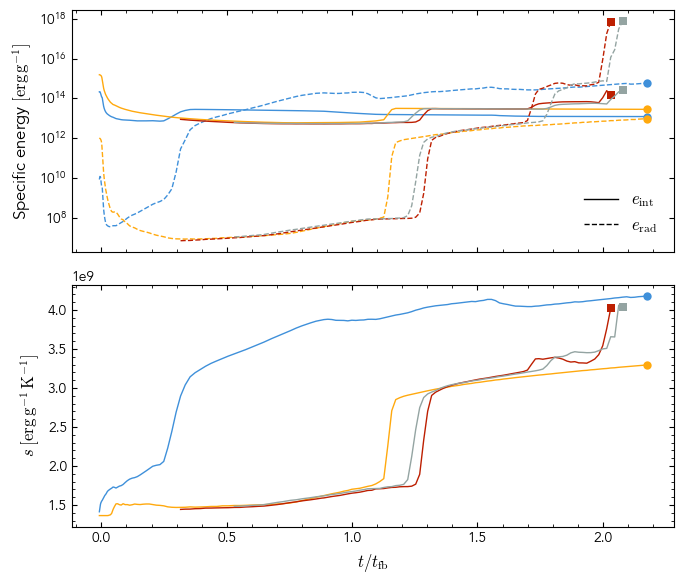

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
for particle_id, track in series_tracks.items():
    time = track["time"] / fallback_time
    color, marker = series_colors[particle_id], track_markers[particle_id]
    axes[0].plot(
        time, track["internal_energy"], color=color, marker=marker, markevery=[-1]
    )
    axes[0].plot(
        time,
        track["radiation_energy"],
        "--",
        color=color,
        marker=marker,
        markevery=[-1],
    )
    axes[1].plot(time, track["entropy"], color=color, marker=marker, markevery=[-1])
axes[0].set(yscale="log", ylabel=r"Specific energy $[\mathrm{erg\,g^{-1}}]$")
axes[0].legend(
    handles=[
        Line2D([], [], color="k", label=r"$e_\mathrm{int}$"),
        Line2D([], [], color="k", linestyle="--", label=r"$e_\mathrm{rad}$"),
    ]
)
axes[1].set(
    xlabel=r"$t/t_\mathrm{fb}$",
    ylabel=r"$s\;[\mathrm{erg\,g^{-1}\,K^{-1}}]$",
)
fig.tight_layout()
plt.show()

### Gas and radiation temperatures
Use RICH’s stored gas temperature and $T_\mathrm{rad}=(\rho e_\mathrm{rad}/a)^{1/4}$, with $a=4\sigma_\mathrm{SB}/c$. This radiation temperature is defined from energy density; it does not assume equilibrium with the gas.


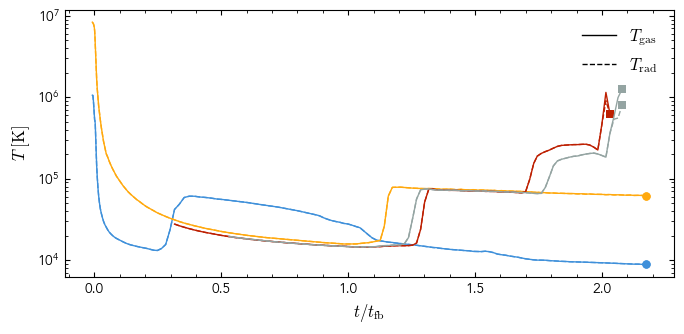

In [11]:
# Erad is specific energy: rho * Erad is radiation energy per volume.
fig, ax = plt.subplots(figsize=(7, 3.5))
for particle_id, track in series_tracks.items():
    time = track["time"] / fallback_time
    T_rad = (track["density"] * track["radiation_energy"] / A_RAD) ** 0.25
    color, marker = series_colors[particle_id], track_markers[particle_id]
    ax.plot(time, track["temperature"], color=color, marker=marker, markevery=[-1])
    ax.plot(time, T_rad, "--", color=color, marker=marker, markevery=[-1])
ax.set(xlabel=r"$t/t_\mathrm{fb}$", ylabel=r"$T\;[\mathrm{K}]$", yscale="log")
ax.legend(
    handles=[
        Line2D([], [], color="k", label=r"$T_\mathrm{gas}$"),
        Line2D([], [], color="k", linestyle="--", label=r"$T_\mathrm{rad}$"),
    ]
)
fig.tight_layout()
plt.show()

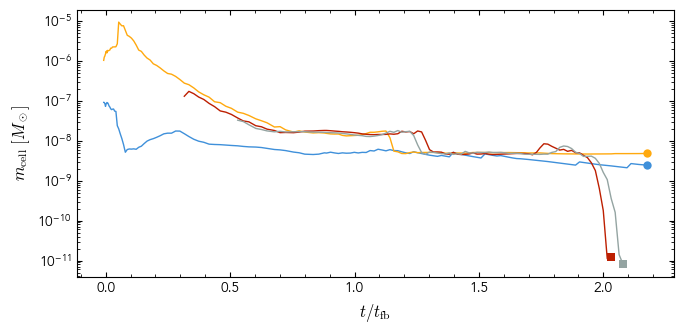

In [8]:
# Cell mass from the snapshot density and volume.
fig, ax = plt.subplots(figsize=(7, 3.5))
for particle_id, track in series_tracks.items():
    time = track["time"] / fallback_time
    mass = (track["density"] * track["volume"]).to("Msun")
    ax.plot(
        time,
        mass,
        color=series_colors[particle_id],
        marker=track_markers[particle_id],
        markevery=[-1],
    )
ax.set(
    xlabel=r"$t/t_\mathrm{fb}$",
    ylabel=r"$m_\mathrm{cell}\;[M_\odot]$",
    yscale="log",
)
fig.tight_layout()
plt.show()

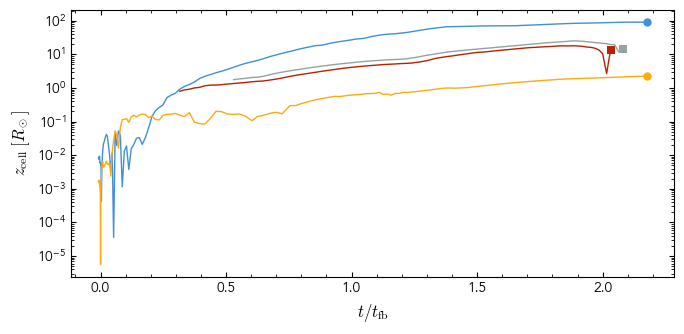

In [14]:
# Cell mass from the snapshot density and volume.
fig, ax = plt.subplots(figsize=(7, 3.5))
for particle_id, track in series_tracks.items():
    time = track["time"] / fallback_time
    zabs = np.abs(track["z"])
    ax.plot(
        time,
        zabs,
        color=series_colors[particle_id],
        marker=track_markers[particle_id],
        markevery=[-1],
    )
ax.set(
    xlabel=r"$t/t_\mathrm{fb}$",
    ylabel=r"$z_\mathrm{cell}\;[R_\odot]$",
    yscale="log",
)
fig.tight_layout()
plt.show()

### Sampled histories: time, BH distance, height, and dissipation
Read every 15,000th archived history (`[::15000]`), retaining complete histories longer than one fallback time with `star > 0.999` throughout. All four panels show the same trajectories and EOS adiabats. Distance is the 3-D BH-centred radius; both lengths are in $R_\odot$. Radius, $|z|$, and volumetric dissipation use logarithmic colour scales. The height and dissipation colour limits are editable at the top of the cell; values outside those ranges saturate at the end colours; non-positive dissipation is grey. `sampled_track_ids` lists the displayed IDs. Run after shared setup, tracking setup, and the BH-frame setup cells.

1006/1006 sampled histories pass: duration > 1 t_fb and star > 0.999 throughout.


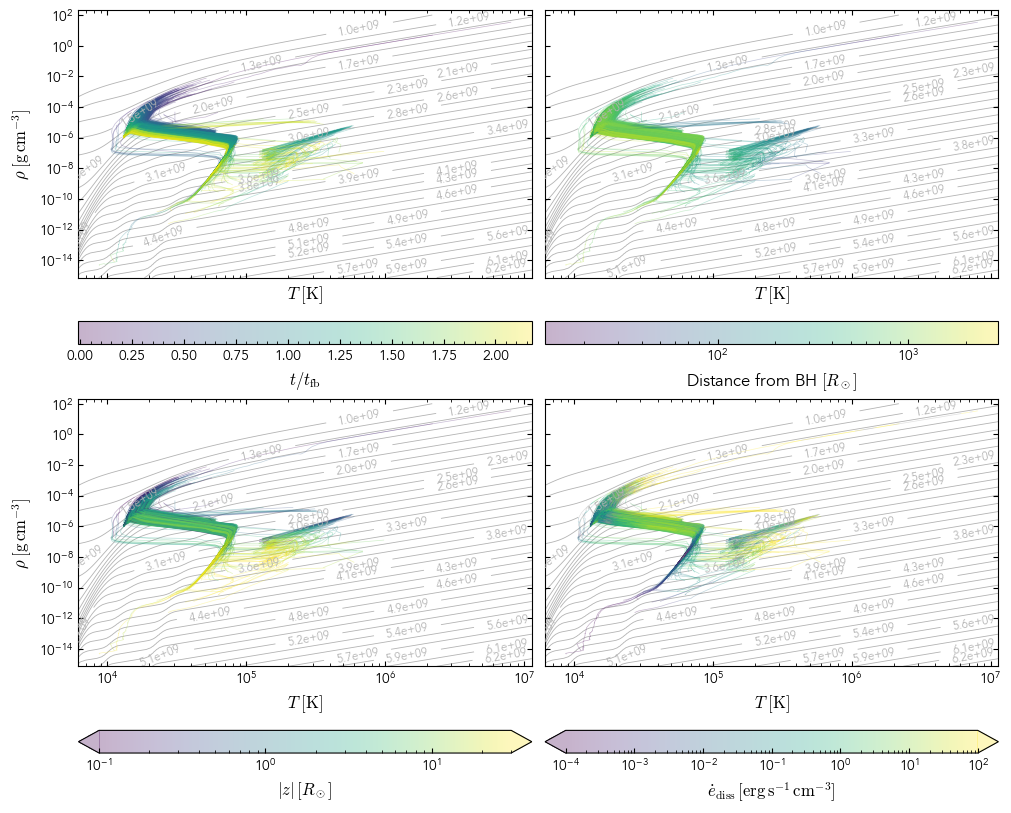

In [7]:
# Read every 15,000th archived history, then apply the complete-history cuts.
ALL_TRACK_STRIDE = 15_000
ALL_TRACK_STAR_MIN = 0.999
HEIGHT_COLOR_LIMITS = u.unyt_array([0.1, 30], "Rsun")
DISSIPATION_COLOR_LIMITS = u.unyt_array([1e-4, 1e2], "erg/(s*cm**3)")

sampled_track_ids = []
sampled_tracks = []
with h5py.File(TRACK_ENSEMBLE_FILE, "r") as archive:
    times = u.unyt_array(archive["time_code"][:], richio.units.tscale)
    tfb = u.unyt_quantity(archive.attrs["fallback_time_code"], richio.units.tscale)
    times_tfb = times / tfb
    time_norm = colors.Normalize(times_tfb.min(), times_tfb.max())
    candidate_rows = range(0, len(archive["ids"]), ALL_TRACK_STRIDE)
    for row in candidate_rows:
        start, stop = archive["offsets"][row : row + 2]
        indices = archive["snapshot_index"][start:stop]
        # Columns: density, temperature, dissipation, star, removed, X, Y, Z.
        values = archive["values"][start:stop, :8]
        if not (
            times[indices[-1]] - times[indices[0]] > tfb
            and np.all(values[:, 3] > ALL_TRACK_STAR_MIN)
        ):
            continue
        sampled_track_ids.append(int(archive["ids"][row]))
        density = u.unyt_array(values[:, 0], richio.units.get_unit("Density")).to(
            "g/cm**3"
        )
        temperature = u.unyt_array(values[:, 1], "K")
        # LineCollection needs numerical vertices with mixed coordinate units.
        vertices = np.column_stack(
            (temperature.to_value("K"), density.to_value("g/cm**3"))
        )
        segments = np.stack((vertices[:-1], vertices[1:]), axis=1)
        # Correct the early star-centred snapshots to the BH frame.
        position = u.unyt_array(values[:, 5:8], richio.units.lscale).to("Rsun")
        position += frame_offset[indices]
        sampled_tracks.append(
            {
                "segments": segments,
                "density": density,
                "temperature": temperature,
                "position": position,
                "snapshot": catalogue_snapshots[indices],
                "time": times_tfb[indices],
                "radius": np.sqrt(np.sum(position**2, axis=1)),
                "height": abs(position[:, 2]),
                "dissipation": u.unyt_array(
                    values[:, 2], richio.units.get_unit("Dissipation")
                ).to("erg/(s*cm**3)"),
            }
        )

radius_norm = colors.LogNorm(
    min(track["radius"].min() for track in sampled_tracks),
    max(track["radius"].max() for track in sampled_tracks),
)
height_norm = colors.LogNorm(*HEIGHT_COLOR_LIMITS)
dissipation_norm = colors.LogNorm(*DISSIPATION_COLOR_LIMITS)
# Keep non-positive dissipation segments visible in grey on the logarithmic scale.
sample_cmap = plt.get_cmap(TRACK_CMAP).with_extremes(bad="0.6")
fig, axes = plt.subplots(
    2, 2, figsize=(10, 8), sharex=True, sharey=True, layout="constrained"
)
for ax, field, norm, label in zip(
    axes.flat,
    ("time", "radius", "height", "dissipation"),
    (time_norm, radius_norm, height_norm, dissipation_norm),
    (
        r"$t/t_{\rm fb}$",
        r"Distance from BH $[R_\odot]$",
        r"$|z|\,[R_\odot]$",
        r"$\dot{e}_\mathrm{diss}\,[\mathrm{erg\,s^{-1}\,cm^{-3}}]$",
    ),
):
    for track in sampled_tracks:
        quantity = track[field]
        trajectory = LineCollection(
            track["segments"], cmap=sample_cmap, norm=norm, linewidths=0.5, alpha=0.3
        )
        trajectory.set_array((quantity[:-1] + quantity[1:]) / 2)
        ax.add_collection(trajectory)
    ax.set_xlabel(r"$T\;[\mathrm{K}]$")
    fig.colorbar(
        trajectory,
        ax=ax,
        orientation="horizontal",
        label=label,
        extend="both" if field in ("height", "dissipation") else "neither",
    )
# Add all collections before switching the shared axes to logarithmic scales.
for ax in axes.flat:
    ax.set(xscale="log", yscale="log")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\rho\;[\mathrm{g\,cm^{-3}}]$")
axes[0, 0].autoscale_view()
temperature_limits, density_limits = axes[0, 0].get_xlim(), axes[0, 0].get_ylim()

# EOS adiabats, restricted to the tabulated domain.
T_grid = u.unyt_array(
    np.geomspace(
        max(temperature_limits[0], 1e3),
        min(temperature_limits[1], 5e7),
        ADIABAT_GRID_SIZE,
    ),
    "K",
)
rho_grid = u.unyt_array(
    np.geomspace(
        max(density_limits[0], 1e-21),
        min(density_limits[1], 1e2),
        ADIABAT_GRID_SIZE,
    ),
    "g/cm**3",
)
P_grid = richio.eos.dT2p(rho_grid[:, None], T_grid[None, :])
s_grid = richio.eos.dp2s(rho_grid[:, None], P_grid)
for ax in axes.flat:
    adiabats = ax.contour(
        T_grid,
        rho_grid,
        s_grid.to_value("erg/(g*K)"),
        levels=ADIABAT_LEVELS,
        colors="0.7",
        linewidths=0.6,
        zorder=1,
    )
    ax.clabel(adiabats, inline=True, fmt="%.1e", fontsize="x-small")
    ax.set(xlim=temperature_limits, ylim=density_limits)
print(
    f"{len(sampled_track_ids)}/{len(candidate_rows)} sampled histories pass: "
    f"duration > 1 t_fb and star > {ALL_TRACK_STAR_MIN} throughout."
)
plt.show()

### Paths reaching hot, dilute states after one fallback time
Select from the ~1,000 sampled paths above: at least one point must satisfy all three cuts simultaneously. Plot the whole stored trajectory; open markers show starts. The three colour scales match the phase diagrams.

84/1006 sampled paths pass the joint cut.


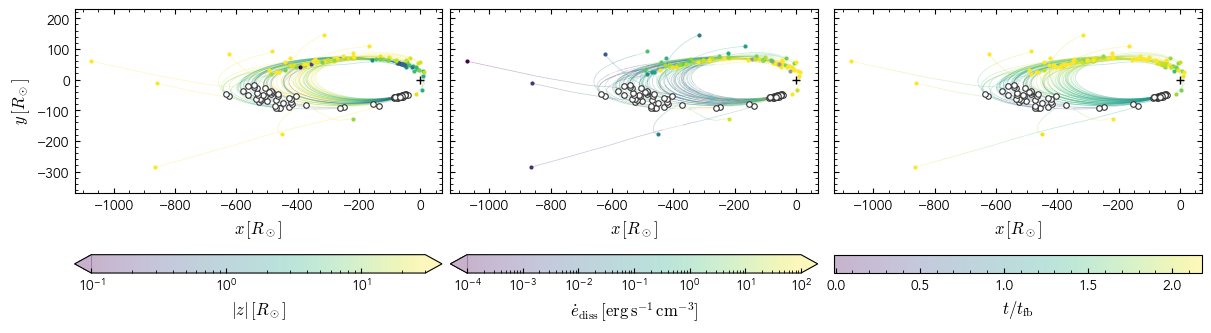

In [8]:
HOT_T_MIN = 1e5 * u.K
HOT_TIME_MIN_TFB = 1
HOT_RHO_MAX = u.unyt_quantity(1e-4, "g/cm**3")

# The three conditions must hold at the same point; then keep the whole path.
selected_tracks = {
    particle_id: track
    for particle_id, track in zip(sampled_track_ids, sampled_tracks)
    if np.any(
        (track["temperature"] > HOT_T_MIN)
        & (track["time"] > HOT_TIME_MIN_TFB)
        & (track["density"] < HOT_RHO_MAX)
    )
}
print(f"{len(selected_tracks)}/{len(sampled_tracks)} sampled paths pass the joint cut.")

xy = np.concatenate([track["position"][:, :2] for track in selected_tracks.values()])
centre = (xy.min(axis=0) + xy.max(axis=0)) / 2
width = 1.1 * max(np.ptp(xy[:, 0]), 2 * np.ptp(xy[:, 1]))
fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.8), sharex=True, sharey=True, layout="constrained"
)
for ax, field, norm, label in zip(
    axes,
    ("height", "dissipation", "time"),
    (height_norm, dissipation_norm, time_norm),
    (
        r"$|z|\,[R_\odot]$",
        r"$\dot{e}_\mathrm{diss}\,[\mathrm{erg\,s^{-1}\,cm^{-3}}]$",
        r"$t/t_{\rm fb}$",
    ),
):
    for track in selected_tracks.values():
        xy = track["position"][:, :2]
        segments = np.stack((xy[:-1], xy[1:]), axis=1)
        quantity = track[field]
        trajectory = LineCollection(
            segments, cmap=sample_cmap, norm=norm, linewidths=0.5, alpha=0.3
        )
        trajectory.set_array((quantity[:-1] + quantity[1:]) / 2)
        ax.add_collection(trajectory)
    for track in selected_tracks.values():
        xy = track["position"][:, :2]
        ax.plot(xy[0, 0], xy[0, 1], "o", mfc="white", mec="0.2", mew=0.8, ms=4)
        ax.plot(
            xy[-1, 0], xy[-1, 1], "o", color=sample_cmap(norm(track[field][-1])), ms=3
        )
    ax.plot(0, 0, "k+", mew=1)
    ax.set(
        xlim=centre[0] + width * np.array([-0.5, 0.5]),
        ylim=centre[1] + width * np.array([-0.25, 0.25]),
        xlabel=r"$x\,[R_\odot]$",
    )
    ax.set_aspect("equal")
    fig.colorbar(
        trajectory,
        ax=ax,
        orientation="horizontal",
        label=label,
        extend="both" if field != "time" else "neither",
    )
axes[0].set_ylabel(r"$y\,[R_\odot]$")
plt.show()

### Selected cells on density and temperature slices
Density above, temperature below, at the nearest saved times to 1, 1.5, and 2 fallback times. Blue rings show the selected IDs present in each raw snapshot, projected onto the $z=0$ slice. The printed counts identify missing cells.

In [10]:
# Read the backgrounds once; both six-panel figures below reuse them.
SLICE_TFBS = [1.0, 1.5, 2.0]
SLICE_BOX = u.unyt_array([-1500, -425, 100, 375], "Rsun")  # xmin, ymin, xmax, ymax
SLICE_RES = (600, 300)
SLICE_DENSITY_LIMITS = u.unyt_array([1e-12, 1e-5], "g/cm**3")
SLICE_TEMPERATURE_LIMITS = u.unyt_array([1e4, 1e7], "K")
slice_density_norm = colors.LogNorm(*SLICE_DENSITY_LIMITS)
slice_temperature_norm = colors.LogNorm(*SLICE_TEMPERATURE_LIMITS)

# Reuse the ID reader to locate selected cells even outside their archived intervals.
sys.path.insert(0, os.path.join(REPO_DIR, "works", "shock-tde"))
cell_history = importlib.import_module("trace-cell-histories")
snapshot_paths = {
    int(os.path.basename(path).rsplit("_", 1)[-1].split(".")[0]): path
    for path in dev.DATAPATHS(TRACK_RUN)
}
catalogue_tfb = u.unyt_array(catalogue_time_code, richio.units.tscale) / fallback_time
slice_rows = [np.argmin(abs(catalogue_tfb - time)) for time in SLICE_TFBS]
targets = np.array(sorted(set(selected_tracks) | set(series_tracks)), dtype=np.uint64)
slice_maps = []
for row in slice_rows:
    snapnum = catalogue_snapshots[row]
    path = snapshot_paths[snapnum]
    print(
        f"Reading snapshot {snapnum}: t/tfb = {float(catalogue_tfb[row]):.4f}",
        flush=True,
    )
    ranks, _, _ = cell_history._rank_layout(path)
    positions = {}
    for _, (ids, coordinates) in cell_history._rank_results(
        path, ranks, targets, None, 1, fields=("X", "Y", "Z")
    ):
        for particle_id, xyz in zip(ids, coordinates):
            positions[int(particle_id)] = (
                u.unyt_array(xyz, richio.units.lscale).to("Rsun") + frame_offset[row]
            )
    found = sum(particle_id in positions for particle_id in selected_tracks)
    print(
        f"Selected IDs present: {found}/{len(selected_tracks)}; absent IDs are not marked.",
        flush=True,
    )
    slice_snap = richio.load(path)
    # One nearest-cell map for both fields. These snapshots are already BH-centred.
    grid_indices, slice_x, slice_y = slice_snap.to_2dgrid(
        res=SLICE_RES, box_size=SLICE_BOX.to(richio.units.lscale)
    )
    slice_maps.append(
        {
            "density": slice_snap["Density"][grid_indices].to("g/cm**3"),
            "temperature": slice_snap["Temperature"][grid_indices],
            "x": slice_x.to("Rsun"),
            "y": slice_y.to("Rsun"),
            "positions": positions,
        }
    )
    slice_snap.f.close()
    del slice_snap

Reading snapshot 77: t/tfb = 0.9990


Selected IDs present: 39/84; absent IDs are not marked.


Reading snapshot 108: t/tfb = 1.4925


Selected IDs present: 84/84; absent IDs are not marked.


Reading snapshot 140: t/tfb = 1.9997


Selected IDs present: 60/84; absent IDs are not marked.


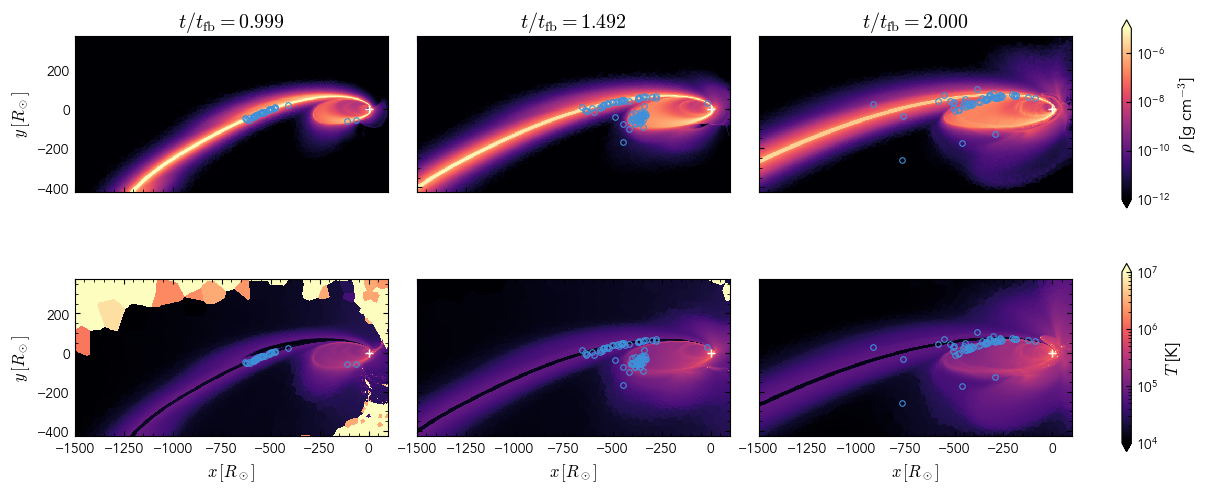

In [11]:
fig, axes = plt.subplots(
    2, 3, figsize=(12, 5), sharex=True, sharey=True, layout="constrained"
)
for plot_row, (field, norm, label) in enumerate(
    (
        ("density", slice_density_norm, r"$\rho$ [g cm$^{-3}$]"),
        ("temperature", slice_temperature_norm, r"$T$ [K]"),
    )
):
    for column, (row, maps) in enumerate(zip(slice_rows, slice_maps)):
        ax = axes[plot_row, column]
        im = ax.pcolormesh(maps["x"], maps["y"], maps[field].T, norm=norm, cmap="magma")
        # x-y projections of every selected ID present in this raw snapshot.
        points = u.unyt_array(
            [
                maps["positions"][particle_id][:2]
                for particle_id in selected_tracks
                if particle_id in maps["positions"]
            ],
            "Rsun",
        )
        ax.plot(points[:, 0], points[:, 1], "o", mfc="none", mec="C0", mew=0.8, ms=4)
        ax.plot(0, 0, "+", color="white", mew=1)
        ax.set(xlim=SLICE_BOX[[0, 2]], ylim=SLICE_BOX[[1, 3]])
        ax.set_aspect("equal")
        if plot_row == 0:
            ax.set_title(rf"$t/t_{{\rm fb}}={float(catalogue_tfb[row]):.3f}$")
        else:
            ax.set_xlabel(r"$x\,[R_\odot]$")
    axes[plot_row, 0].set_ylabel(r"$y\,[R_\odot]$")
    fig.colorbar(im, ax=axes[plot_row], label=label, extend="both", shrink=0.8)
plt.show()

### Density and temperature slices with the four example cells
Density above, temperature below, on the $z=0$ plane. Markers show the four cells' projected x–y positions in their C0–C3 colours. Both slice figures reuse `slice_maps`; edit their colour limits in the loading cell.

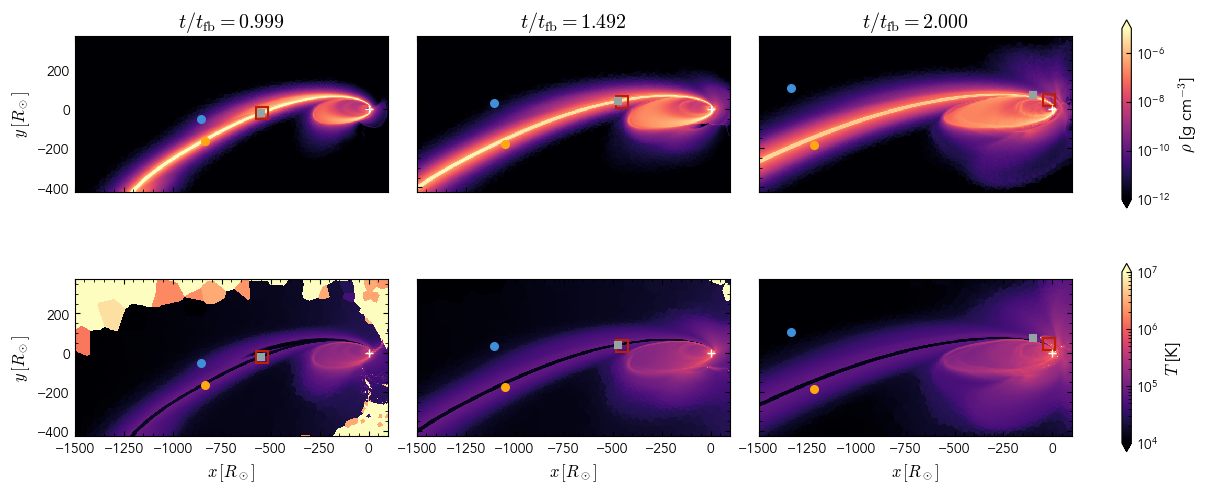

In [13]:
fig, axes = plt.subplots(
    2, 3, figsize=(12, 5), sharex=True, sharey=True, layout="constrained"
)
for plot_row, (field, norm, label) in enumerate(
    (
        ("density", slice_density_norm, r"$\rho$ [g cm$^{-3}$]"),
        ("temperature", slice_temperature_norm, r"$T$ [K]"),
    )
):
    for column, (row, maps) in enumerate(zip(slice_rows, slice_maps)):
        ax = axes[plot_row, column]
        im = ax.pcolormesh(maps["x"], maps["y"], maps[field].T, norm=norm, cmap="magma")
        for index, particle_id in enumerate(series_tracks):
            point = maps["positions"][particle_id]
            # Larger hollow C2 square keeps both nearly coincident nozzle cells visible.
            ax.plot(
                point[0],
                point[1],
                marker=track_markers[particle_id],
                linestyle="none",
                color=series_colors[particle_id],
                markerfacecolor="none" if index == 2 else series_colors[particle_id],
                markersize=9 if index == 2 else 5,
                markeredgewidth=1.5,
            )
        ax.plot(0, 0, "+", color="white", mew=1)
        ax.set(xlim=SLICE_BOX[[0, 2]], ylim=SLICE_BOX[[1, 3]])
        ax.set_aspect("equal")
        if plot_row == 0:
            ax.set_title(rf"$t/t_{{\rm fb}}={float(catalogue_tfb[row]):.3f}$")
        else:
            ax.set_xlabel(r"$x\,[R_\odot]$")
    axes[plot_row, 0].set_ylabel(r"$y\,[R_\odot]$")
    fig.colorbar(im, ax=axes[plot_row], label=label, extend="both", shrink=0.8)
plt.show()